Setup de Spark 

In [1]:
import os
import sys

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["HADOOP_CONF_DIR"] = os.path.expanduser("~/hadoop/etc/hadoop")
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, avg, round as spark_round, lower, when
import matplotlib.pyplot as plt

spark = (
    SparkSession.builder
    .appName("Gaming Mental Health - Graphs")
    .master("local[*]")
    .getOrCreate()
)

spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/16 13:09:41 WARN Utils: Your hostname, DESKTOP-42F3QCS, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/07/16 13:09:41 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/16 13:09:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/07/16 13:09:42 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Chargement du dataset

In [2]:
merged_path = "hdfs://localhost:9000/projet/gaming_mental_health/output/merged_dataset"

df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(merged_path)
)

print("Nombre de lignes :", df.count())
print("Nombre de colonnes :", len(df.columns))

df.printSchema()
df.show(5)

Nombre de lignes : 1029
Nombre de colonnes : 27
root
 |-- record_id: string (nullable = true)
 |-- age: double (nullable = true)
 |-- gender: string (nullable = true)
 |-- daily_gaming_hours: double (nullable = true)
 |-- game_genre: string (nullable = true)
 |-- primary_game: string (nullable = true)
 |-- gaming_platform: string (nullable = true)
 |-- sleep_hours: double (nullable = true)
 |-- sleep_quality: string (nullable = true)
 |-- sleep_disruption_frequency: string (nullable = true)
 |-- academic_work_performance: string (nullable = true)
 |-- grades_gpa: double (nullable = true)
 |-- work_productivity_score: double (nullable = true)
 |-- mood_state: string (nullable = true)
 |-- mood_swing_frequency: string (nullable = true)
 |-- withdrawal_symptoms: boolean (nullable = true)
 |-- loss_of_other_interests: boolean (nullable = true)
 |-- continued_despite_problems: boolean (nullable = true)
 |-- eye_strain: boolean (nullable = true)
 |-- back_neck_pain: boolean (nullable = true)

26/07/16 13:09:47 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+---------+----+------+------------------+-------------+--------------+---------------+-----------+-------------+--------------------------+-------------------------+----------+-----------------------+----------+--------------------+-------------------+-----------------------+--------------------------+----------+--------------+----------------+---------------------+----------------------+--------------------------------+-------------------------+------------+---------------------------+
|record_id| age|gender|daily_gaming_hours|   game_genre|  primary_game|gaming_platform|sleep_hours|sleep_quality|sleep_disruption_frequency|academic_work_performance|grades_gpa|work_productivity_score|mood_state|mood_swing_frequency|withdrawal_symptoms|loss_of_other_interests|continued_despite_problems|eye_strain|back_neck_pain|weight_change_kg|exercise_hours_weekly|social_isolation_score|face_to_face_social_hours_weekly|monthly_game_spending_usd|years_gaming|gaming_addiction_risk_level|
+---------+---

## Gender distribution

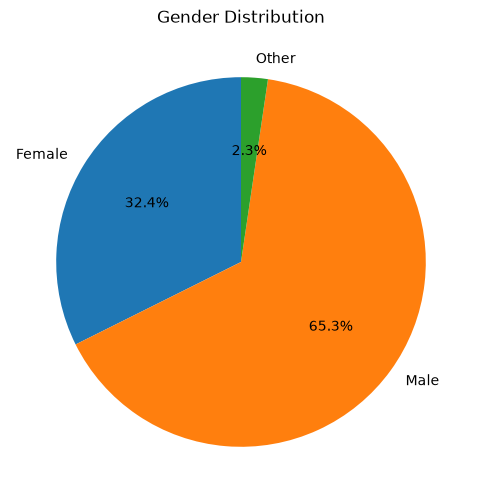

In [3]:
gender_pd = (
    df.groupBy("gender")
    .agg(count("*").alias("count"))
    .orderBy("gender")
    .toPandas()
)

plt.figure(figsize=(6, 6))
plt.pie(
    gender_pd["count"],
    labels=gender_pd["gender"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Gender Distribution")
plt.show()

## 2. Game genre ranking

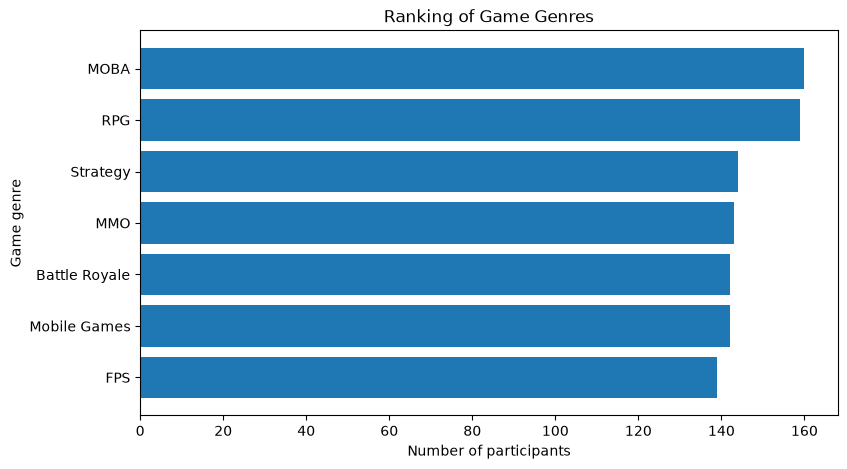

,game_genre,count
0,MOBA,160
1,RPG,159
2,Strategy,144
3,MMO,143
4,Battle Royale,142
5,Mobile Games,142
6,FPS,139


In [4]:
genre_pd = (
    df.groupBy("game_genre")
    .agg(count("*").alias("count"))
    .orderBy(col("count").desc())
    .toPandas()
)

plt.figure(figsize=(9, 5))
plt.barh(genre_pd["game_genre"], genre_pd["count"])
plt.xlabel("Number of participants")
plt.ylabel("Game genre")
plt.title("Ranking of Game Genres")
plt.gca().invert_yaxis()
plt.show()

genre_pd

## 3. Average daily gaming hours by game genre

This chart compares the average number of daily gaming hours depending on the main game genre.

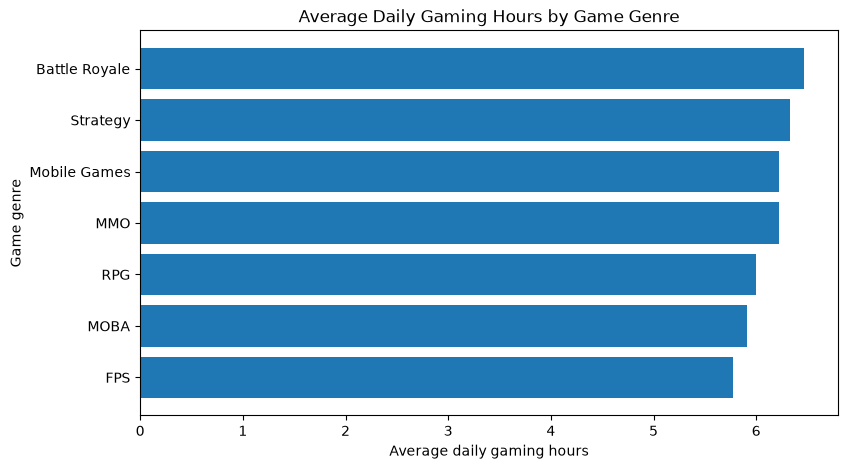

,game_genre,avg_daily_gaming_hours
0,Battle Royale,6.47
1,Strategy,6.33
2,Mobile Games,6.22
3,MMO,6.22
4,RPG,6.00
5,MOBA,5.91
6,FPS,5.77


In [5]:
from pyspark.sql.functions import col, avg, round as spark_round
import matplotlib.pyplot as plt

genre_hours_pd = (
    df.groupBy("game_genre")
    .agg(spark_round(avg("daily_gaming_hours"), 2).alias("avg_daily_gaming_hours"))
    .orderBy(col("avg_daily_gaming_hours").desc())
    .toPandas()
)

plt.figure(figsize=(9, 5))
plt.barh(
    genre_hours_pd["game_genre"],
    genre_hours_pd["avg_daily_gaming_hours"]
)
plt.xlabel("Average daily gaming hours")
plt.ylabel("Game genre")
plt.title("Average Daily Gaming Hours by Game Genre")
plt.gca().invert_yaxis()
plt.show()

genre_hours_pd

## 4. Physical symptoms related to gaming

This chart shows the percentage of participants reporting eye strain and back/neck pain.

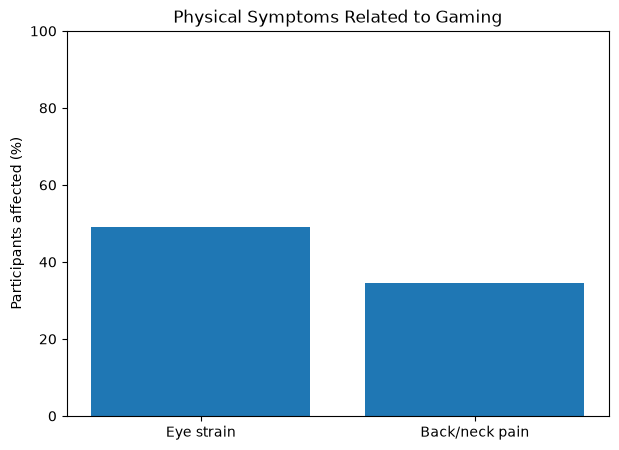

,symptom,percentage
0,Eye strain,48.98
1,Back/neck pain,34.50


In [6]:
from pyspark.sql.functions import when, lower, avg, round as spark_round, col

symptoms_df = df.select(
    when(lower(col("eye_strain").cast("string")) == "true", 1).otherwise(0).alias("eye_strain_num"),
    when(lower(col("back_neck_pain").cast("string")) == "true", 1).otherwise(0).alias("back_neck_pain_num")
)

symptoms_pd = symptoms_df.select(
    spark_round(avg("eye_strain_num") * 100, 2).alias("Eye strain"),
    spark_round(avg("back_neck_pain_num") * 100, 2).alias("Back/neck pain")
).toPandas()

symptoms_pd = symptoms_pd.melt(var_name="symptom", value_name="percentage")

plt.figure(figsize=(7, 5))
plt.bar(symptoms_pd["symptom"], symptoms_pd["percentage"])
plt.ylabel("Participants affected (%)")
plt.title("Physical Symptoms Related to Gaming")
plt.ylim(0, 100)
plt.show()

symptoms_pd

## 5. Eye strain by gaming platform

This chart compares the percentage of participants reporting eye strain depending on their main gaming platform.

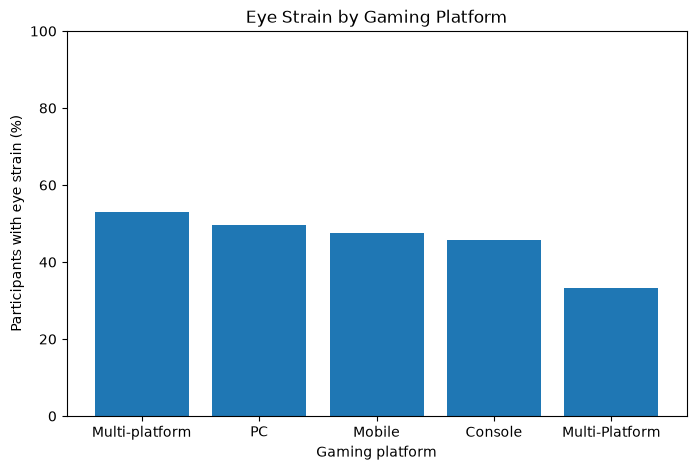

,gaming_platform,eye_strain_percentage
0,Multi-platform,53.08
1,PC,49.62
2,Mobile,47.53
3,Console,45.80
4,Multi-Platform,33.33


In [7]:
platform_eye_pd = (
    df.withColumn(
        "eye_strain_num",
        when(lower(col("eye_strain").cast("string")) == "true", 1).otherwise(0)
    )
    .groupBy("gaming_platform")
    .agg(spark_round(avg("eye_strain_num") * 100, 2).alias("eye_strain_percentage"))
    .orderBy(col("eye_strain_percentage").desc())
    .toPandas()
)

plt.figure(figsize=(8, 5))
plt.bar(
    platform_eye_pd["gaming_platform"],
    platform_eye_pd["eye_strain_percentage"]
)
plt.xlabel("Gaming platform")
plt.ylabel("Participants with eye strain (%)")
plt.title("Eye Strain by Gaming Platform")
plt.ylim(0, 100)
plt.show()

platform_eye_pd

## 6. Back and neck pain by gaming platform

This chart compares back and neck pain reports depending on the main gaming platform.

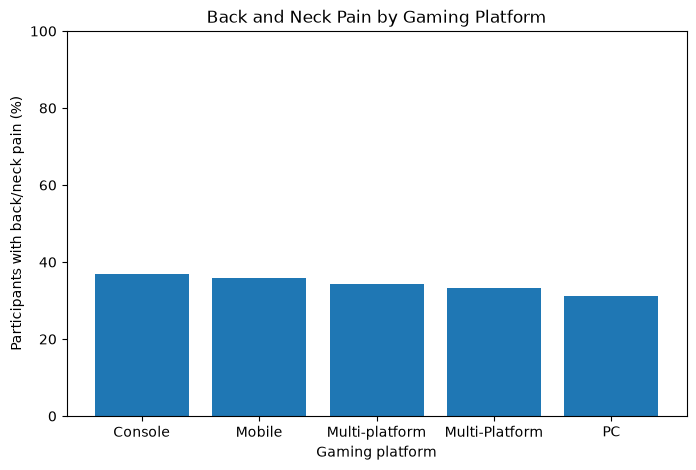

,gaming_platform,back_neck_pain_percentage
0,Console,36.97
1,Mobile,35.74
2,Multi-platform,34.23
3,Multi-Platform,33.33
4,PC,31.30


In [8]:
platform_back_pd = (
    df.withColumn(
        "back_neck_pain_num",
        when(lower(col("back_neck_pain").cast("string")) == "true", 1).otherwise(0)
    )
    .groupBy("gaming_platform")
    .agg(spark_round(avg("back_neck_pain_num") * 100, 2).alias("back_neck_pain_percentage"))
    .orderBy(col("back_neck_pain_percentage").desc())
    .toPandas()
)

plt.figure(figsize=(8, 5))
plt.bar(
    platform_back_pd["gaming_platform"],
    platform_back_pd["back_neck_pain_percentage"]
)
plt.xlabel("Gaming platform")
plt.ylabel("Participants with back/neck pain (%)")
plt.title("Back and Neck Pain by Gaming Platform")
plt.ylim(0, 100)
plt.show()

platform_back_pd

## 7. Mood state distribution

This chart shows the most common mood states reported by participants.

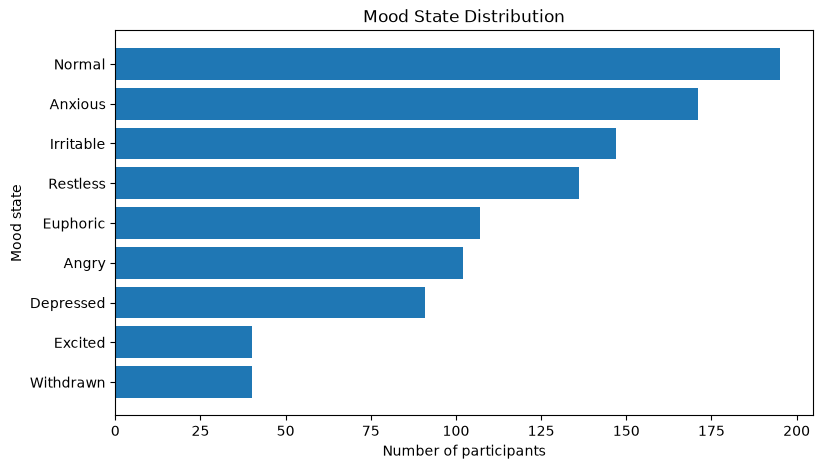

,mood_state,count
0,Normal,195
1,Anxious,171
2,Irritable,147
3,Restless,136
4,Euphoric,107
5,Angry,102
6,Depressed,91
7,Excited,40
8,Withdrawn,40


In [9]:
from pyspark.sql.functions import count

mood_pd = (
    df.groupBy("mood_state")
    .agg(count("*").alias("count"))
    .orderBy(col("count").desc())
    .toPandas()
)

plt.figure(figsize=(9, 5))
plt.barh(mood_pd["mood_state"], mood_pd["count"])
plt.xlabel("Number of participants")
plt.ylabel("Mood state")
plt.title("Mood State Distribution")
plt.gca().invert_yaxis()
plt.show()

mood_pd

## 8. Gaming-related symptoms comparison

This chart compares the percentage of participants reporting withdrawal symptoms, loss of interest, and continued gaming despite problems.

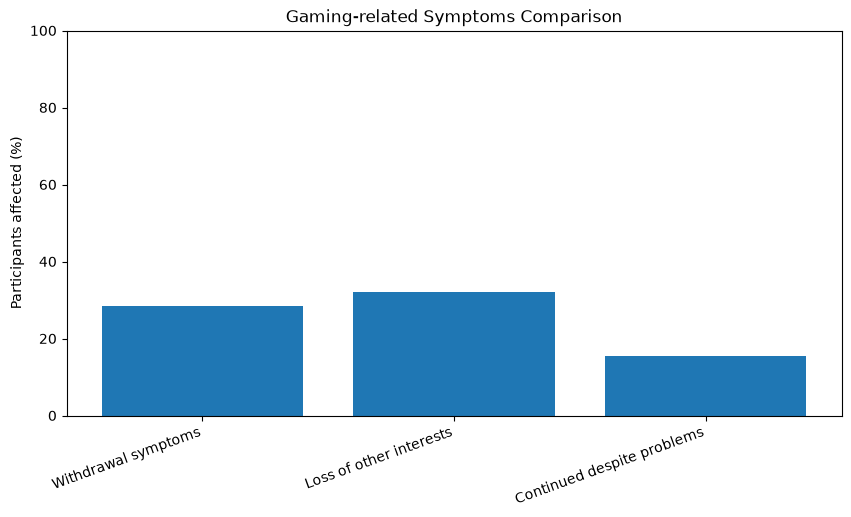

,symptom,percentage
0,Withdrawal symptoms,28.47
1,Loss of other interests,32.07
2,Continued despite problems,15.55


In [10]:
addiction_symptoms_df = df.select(
    when(lower(col("withdrawal_symptoms").cast("string")) == "true", 1).otherwise(0).alias("withdrawal_symptoms_num"),
    when(lower(col("loss_of_other_interests").cast("string")) == "true", 1).otherwise(0).alias("loss_of_other_interests_num"),
    when(lower(col("continued_despite_problems").cast("string")) == "true", 1).otherwise(0).alias("continued_despite_problems_num")
)

addiction_symptoms_pd = addiction_symptoms_df.select(
    spark_round(avg("withdrawal_symptoms_num") * 100, 2).alias("Withdrawal symptoms"),
    spark_round(avg("loss_of_other_interests_num") * 100, 2).alias("Loss of other interests"),
    spark_round(avg("continued_despite_problems_num") * 100, 2).alias("Continued despite problems")
).toPandas()

addiction_symptoms_pd = addiction_symptoms_pd.melt(
    var_name="symptom",
    value_name="percentage"
)

plt.figure(figsize=(10, 5))
plt.bar(
    addiction_symptoms_pd["symptom"],
    addiction_symptoms_pd["percentage"]
)
plt.ylabel("Participants affected (%)")
plt.title("Gaming-related Symptoms Comparison")
plt.ylim(0, 100)
plt.xticks(rotation=20, ha="right")
plt.show()

addiction_symptoms_pd